# Testing
## Zuzüge von auswärts nach Monat, Stadtquartier, Geschlecht, Altersgruppe und Herkunft

### Kurzbeschreibung
Beschreibung
Anzahl Zuzüge von auswärts nach Monat, Altersgruppe, Geschlecht, Herkunft, Stadtkreis und Stadtquartier.

Im aktuellen Jahr handelt es sich um provisorische Daten. Diese können laufend korrigiert werden. Erst mit dem Jahresabschluss werden die Daten definitiv.

Datum: 16.08.2024


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_monat_zuz_quartier_geschl_ag_herkunft_od3530

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_zuz_quartier_geschl_ag_herkunft_od3530


### Importiere die notwendigen Packages

In [1]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [2]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [3]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [4]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [5]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [6]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [7]:
package_name = "bev_monat_zuz_quartier_geschl_ag_herkunft_od3530"

In [8]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV353OD3530"    
    , datums_attr = ['EreignisDatJahr','StichtagDat']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_zuz_quartier_geschl_ag_herkunft_od3530/download/BEV353OD3530.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_zuz_quartier_geschl_ag_herkunft_od3530 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_monat_zuz_quartier_geschl_ag_herkunft_od3530 

data_source: web


In [9]:
data2betested.tail(2).T

,140285,140286
EreignisDatJahr,2025-01-01 00:00:00,2025-01-01 00:00:00
EreignisDatMM,10,10
EreignisDatMonat,Oktober,Oktober
StichtagDat,2025-10-31 00:00:00,2025-10-31 00:00:00
SexCd,2,2
SexLang,weiblich,weiblich
AlterV20ueber80Sort_noDM,5,5
AlterV20ueber80Cd_noDM,5,5
AlterV20ueber80Kurz_noDM,80 u. älter,80 u. älter
HerkunftCd,1,2


In [10]:
data2betested.dtypes

EreignisDatJahr             datetime64[ns]
EreignisDatMM                        int64
EreignisDatMonat                    object
StichtagDat                 datetime64[ns]
SexCd                                int64
SexLang                             object
AlterV20ueber80Sort_noDM             int64
AlterV20ueber80Cd_noDM               int64
AlterV20ueber80Kurz_noDM            object
HerkunftCd                           int64
HerkunftLang                        object
KreisCd                              int64
KreisLang                           object
QuarCd                               int64
QuarLang                            object
DatenstandCd                        object
DatenstandLang                      object
AnzZuzuWir                           int64
dtype: object

Berechne weitere Attribute falls notwendig

In [11]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDat.astype(str),
        EreignisDatMM_str=lambda x: x.EreignisDatMM.astype(str).str.zfill(2),  # Führende Null hinzufügen
        #Jahr_Monat_str=lambda x: x.EreignisDatJahr.astype(str) + "-" + x.EreignisDatMM_str,
        #Jahr_Monat=lambda x: pd.to_datetime(x.EreignisDatJahr.astype(str) + '-' + x.EreignisDatMM_str, format='%Y-%m')
    )
    .sort_values('StichtagDat', ascending=False)
    )
data2betested.dtypes

EreignisDatJahr             datetime64[ns]
EreignisDatMM                        int64
EreignisDatMonat                    object
StichtagDat                 datetime64[ns]
SexCd                                int64
SexLang                             object
AlterV20ueber80Sort_noDM             int64
AlterV20ueber80Cd_noDM               int64
AlterV20ueber80Kurz_noDM            object
HerkunftCd                           int64
HerkunftLang                        object
KreisCd                              int64
KreisLang                           object
QuarCd                               int64
QuarLang                            object
DatenstandCd                        object
DatenstandLang                      object
AnzZuzuWir                           int64
StichtagDatJahr_str                 object
EreignisDatMM_str                   object
dtype: object

Minimales und maximales Jahr im Datensatz

In [12]:
data_max_date = max(data2betested.StichtagDat).strftime('%Y-%m-%d')
data_min_date = min(data2betested.StichtagDat).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1998-01-31 und ein Maximumjahr von 2025-10-31


### Einfache Datentests

In [13]:
data2betested.sort_values('StichtagDat', ascending=False).head(2).T

,140286,140276
EreignisDatJahr,2025-01-01 00:00:00,2025-01-01 00:00:00
EreignisDatMM,10,10
EreignisDatMonat,Oktober,Oktober
StichtagDat,2025-10-31 00:00:00,2025-10-31 00:00:00
SexCd,2,2
SexLang,weiblich,weiblich
AlterV20ueber80Sort_noDM,5,4
AlterV20ueber80Cd_noDM,5,4
AlterV20ueber80Kurz_noDM,80 u. älter,60-79
HerkunftCd,2,2


In [14]:
#data2betested.dtypes
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 140287 entries, 140286 to 0
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   EreignisDatJahr           140287 non-null  datetime64[ns]
 1   EreignisDatMM             140287 non-null  int64         
 2   EreignisDatMonat          140287 non-null  object        
 3   StichtagDat               140287 non-null  datetime64[ns]
 4   SexCd                     140287 non-null  int64         
 5   SexLang                   140287 non-null  object        
 6   AlterV20ueber80Sort_noDM  140287 non-null  int64         
 7   AlterV20ueber80Cd_noDM    140287 non-null  int64         
 8   AlterV20ueber80Kurz_noDM  140287 non-null  object        
 9   HerkunftCd                140287 non-null  int64         
 10  HerkunftLang              140287 non-null  object        
 11  KreisCd                   140287 non-null  int64         
 12  KreisLa

In [15]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 140,287 rows (observations) and 20 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [16]:
data2betested.describe()

,EreignisDatJahr,EreignisDatMM,StichtagDat,SexCd,AlterV20ueber80Sort_noDM,AlterV20ueber80Cd_noDM,HerkunftCd,KreisCd,QuarCd,AnzZuzuWir
count,140287,140287,140287,140287,140287,140287,140287,140287,140287,140287
mean,2011-05-24 09:34:52.376343040,6,2011-12-03 22:39:10.558498048,2,2,2,1,7,69,8
min,1998-01-01 00:00:00,1,1998-01-31 00:00:00,1,1,1,1,1,11,1
25%,2004-01-01 00:00:00,3,2004-12-31 00:00:00,1,2,2,1,3,34,2
50%,2011-01-01 00:00:00,6,2011-11-30 00:00:00,1,2,2,1,7,72,4
75%,2018-01-01 00:00:00,9,2018-10-31 00:00:00,2,3,3,2,10,101,9
max,2025-01-01 00:00:00,12,2025-10-31 00:00:00,252,5,5,2,12,123,228
std,NaN,3,NaN,1,1,1,0,3,35,12


Welches sind die Quartiere ohne Werte bei BEW?

In [17]:
data2betested[np.isnan(data2betested.AnzZuzuWir)]

,EreignisDatJahr,EreignisDatMM,EreignisDatMonat,StichtagDat,SexCd,SexLang,AlterV20ueber80Sort_noDM,...,QuarCd,QuarLang,DatenstandCd,DatenstandLang,AnzZuzuWir,StichtagDatJahr_str,EreignisDatMM_str


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [18]:
data2betested = data2betested.set_index("StichtagDat")
data2betested = data2betested.sort_index()

In [19]:
data2betested.index.year.unique()

Index([1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
      dtype='int32', name='StichtagDat')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [20]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [21]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,EreignisDatMM,SexCd,AlterV20ueber80Sort_noDM,AlterV20ueber80Cd_noDM,HerkunftCd,KreisCd,QuarCd,AnzZuzuWir
count,"140,287","140,287","140,287","140,287","140,287","140,287","140,287","140,287"
mean,6,2,2,2,1,7,69,8
std,3,1,1,1,0,3,35,12
min,1,1,1,1,1,1,11,1
25%,3,1,2,2,1,3,34,2
50%,6,1,2,2,1,7,72,4
75%,9,2,3,3,2,10,101,9
max,12,252,5,5,2,12,123,228


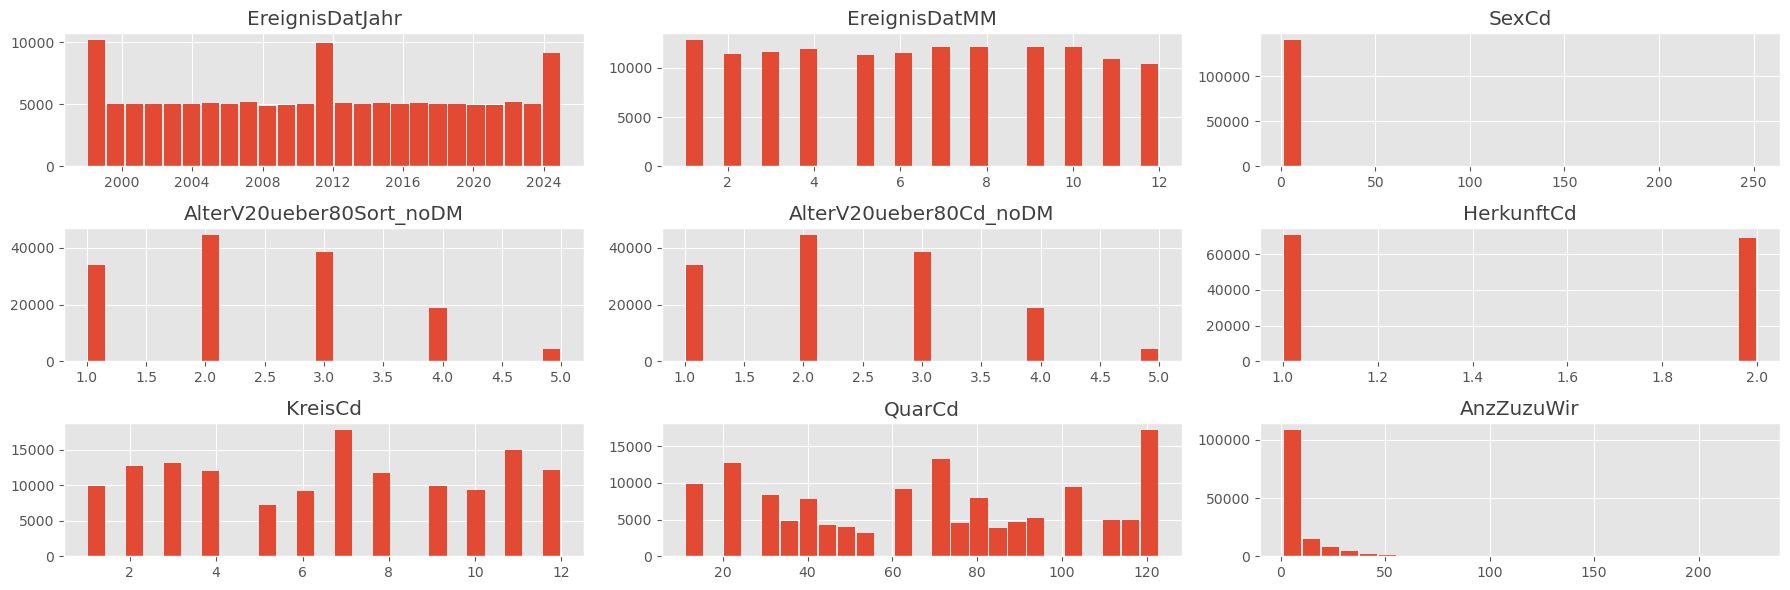

In [22]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [23]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,EreignisDatJahr,EreignisDatMM,EreignisDatMonat,SexCd,SexLang,AlterV20ueber80Sort_noDM,AlterV20ueber80Cd_noDM,...,QuarCd,QuarLang,DatenstandCd,DatenstandLang,AnzZuzuWir,StichtagDatJahr_str,EreignisDatMM_str
StichtagDat,,,,,,,,,,,,,,,


### Nullwerte und Missings?

In [24]:
data2betested.isnull().sum()

EreignisDatJahr             0
EreignisDatMM               0
EreignisDatMonat            0
SexCd                       0
SexLang                     0
AlterV20ueber80Sort_noDM    0
AlterV20ueber80Cd_noDM      0
AlterV20ueber80Kurz_noDM    0
HerkunftCd                  0
HerkunftLang                0
KreisCd                     0
KreisLang                   0
QuarCd                      0
QuarLang                    0
DatenstandCd                0
DatenstandLang              0
AnzZuzuWir                  0
StichtagDatJahr_str         0
EreignisDatMM_str           0
dtype: int64

### Gruppierungen

In [25]:
agg_jahr = data2betested.loc[data_min_date:data_max_date].reset_index()\
    .groupby(['StichtagDat', 'EreignisDatMonat']) \
    .agg(sum_AnzZuzuWir=('AnzZuzuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=False) 
agg_jahr.reset_index().head(6)

,StichtagDat,EreignisDatMonat,sum_AnzZuzuWir
0,2025-10-31,Oktober,3135
1,2025-09-30,September,5597
2,2025-08-31,August,3829
3,2025-07-31,Juli,3253
4,2025-06-30,Juni,2882
5,2025-05-31,Mai,2794


In [26]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftCd', 'HerkunftLang']) \
    .agg(sum_AnzZuzuWir=('AnzZuzuWir', 'sum')) \
    .sort_values('HerkunftCd', ascending=False) 
agg_herk.reset_index().head(3)

,HerkunftCd,HerkunftLang,sum_AnzZuzuWir
0,2,Ausländer*in,689435
1,1,Schweizer*in,460920


In [27]:
agg_age = data2betested.loc[data_max_date]\
    .groupby(['StichtagDat','AlterV20ueber80Sort_noDM', 'AlterV20ueber80Kurz_noDM']) \
    .agg(sum_AnzZuzuWir=('AnzZuzuWir', 'sum')) \
    .sort_values('AlterV20ueber80Sort_noDM', ascending=True) 
agg_age.reset_index().head(11)

,StichtagDat,AlterV20ueber80Sort_noDM,AlterV20ueber80Kurz_noDM,sum_AnzZuzuWir
0,2025-10-31,1,0-19,302
1,2025-10-31,2,20-39,2300
2,2025-10-31,3,40-59,438
3,2025-10-31,4,60-79,80
4,2025-10-31,5,80 u. älter,15


In [28]:
agg_kreis_quart = data2betested.loc[data_max_date]\
    .groupby(['StichtagDat','KreisCd', 'KreisLang', 'QuarCd', 'QuarLang']) \
    .agg(sum_AnzZuzuWir=('AnzZuzuWir', 'sum')) \
    .sort_values('QuarCd', ascending=False) 
agg_kreis_quart.reset_index().head(6)

,StichtagDat,KreisCd,KreisLang,QuarCd,QuarLang,sum_AnzZuzuWir
0,2025-10-31,12,Kreis 12,123,Hirzenbach,59
1,2025-10-31,12,Kreis 12,122,Schwamendingen-Mitte,84
2,2025-10-31,12,Kreis 12,121,Saatlen,40
3,2025-10-31,11,Kreis 11,119,Seebach,211
4,2025-10-31,11,Kreis 11,115,Oerlikon,211
5,2025-10-31,11,Kreis 11,111,Affoltern,158


In [29]:
agg_dstand = data2betested.loc["2023-01":data_max_date]\
    .groupby(['StichtagDat','DatenstandCd','DatenstandLang']) \
    .agg(sum_AnzZuzuWir=('AnzZuzuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=False) 
agg_dstand.reset_index().head(7)

,StichtagDat,DatenstandCd,DatenstandLang,sum_AnzZuzuWir
0,2025-10-31,P,Provisorisch,3135
1,2025-09-30,P,Provisorisch,5597
2,2025-08-31,P,Provisorisch,3829
3,2025-07-31,P,Provisorisch,3253
4,2025-06-30,P,Provisorisch,2882
5,2025-05-31,P,Provisorisch,2794
6,2025-04-30,P,Provisorisch,3055


### Visualisierungen nach Zeitausschnitten

In [30]:
data2betested.head(2).T

StichtagDat,1998-01-31,1998-01-31
EreignisDatJahr,1998-01-01 00:00:00,1998-01-01 00:00:00
EreignisDatMM,1,1
EreignisDatMonat,Januar,Januar
SexCd,1,1
SexLang,männlich,männlich
AlterV20ueber80Sort_noDM,1,1
AlterV20ueber80Cd_noDM,1,1
AlterV20ueber80Kurz_noDM,0-19,0-19
HerkunftCd,1,1
HerkunftLang,Schweizer*in,Schweizer*in


#### Entwicklung Zuzüge nach Herkunft

In [31]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]

myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDat','StichtagDatJahr_str','HerkunftCd', 'HerkunftLang']) \
    .agg(sum_ZuzuWir=('AnzZuzuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=True) 

myAgg1.reset_index().head(3)


,StichtagDat,StichtagDatJahr_str,HerkunftCd,HerkunftLang,sum_ZuzuWir
0,1998-01-31,1998-01-31,1,Schweizer*in,1767
1,1998-01-31,1998-01-31,2,Ausländer*in,1657
2,1998-02-28,1998-02-28,1,Schweizer*in,1082


In [32]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    ,x = 'StichtagDat:T'
    ,y = 'sum_ZuzuWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "HerkunftLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Zuzüger nach Herkunft, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Entwicklung Zuzüge nach Geschlecht

In [33]:
myAgg2 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDat','StichtagDatJahr_str', 'SexCd', 'SexLang']) \
    .agg(sum_ZuzuWir=('AnzZuzuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=True) 

myAgg2.reset_index().head(3)

,StichtagDat,StichtagDatJahr_str,SexCd,SexLang,sum_ZuzuWir
0,1998-01-31,1998-01-31,1,männlich,1823
1,1998-01-31,1998-01-31,2,weiblich,1601
2,1998-02-28,1998-02-28,1,männlich,1298


In [34]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index()
    ,x = 'StichtagDat:T'
    ,y = 'sum_ZuzuWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "SexLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Zuzüger nach Geschlecht, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

#### Faced Grids

In [35]:
sns.set_theme(style="whitegrid")

In [36]:
#.query('HerkunftLang !="Ausland"')
myFG = data2betested\
    .groupby(['StichtagDat','QuarLang', 'QuarCd','HerkunftCd', 'HerkunftLang', ]) \
    .agg(sum_AnzZuzuWir=('AnzZuzuWir', 'sum')) \
    .sort_values('QuarCd', ascending=True) 
myFG.reset_index()

,StichtagDat,QuarLang,QuarCd,HerkunftCd,HerkunftLang,sum_AnzZuzuWir
0,2008-04-30,Rathaus,11,1,Schweizer*in,22
1,2008-08-31,Rathaus,11,1,Schweizer*in,19
2,2008-08-31,Rathaus,11,2,Ausländer*in,72
3,2001-01-31,Rathaus,11,1,Schweizer*in,27
4,2016-04-30,Rathaus,11,1,Schweizer*in,11
...,...,...,...,...,...,...
22673,2003-05-31,Hirzenbach,123,2,Ausländer*in,38
22674,2007-10-31,Hirzenbach,123,1,Schweizer*in,45
22675,2023-10-31,Hirzenbach,123,2,Ausländer*in,50
22676,2009-05-31,Hirzenbach,123,1,Schweizer*in,19


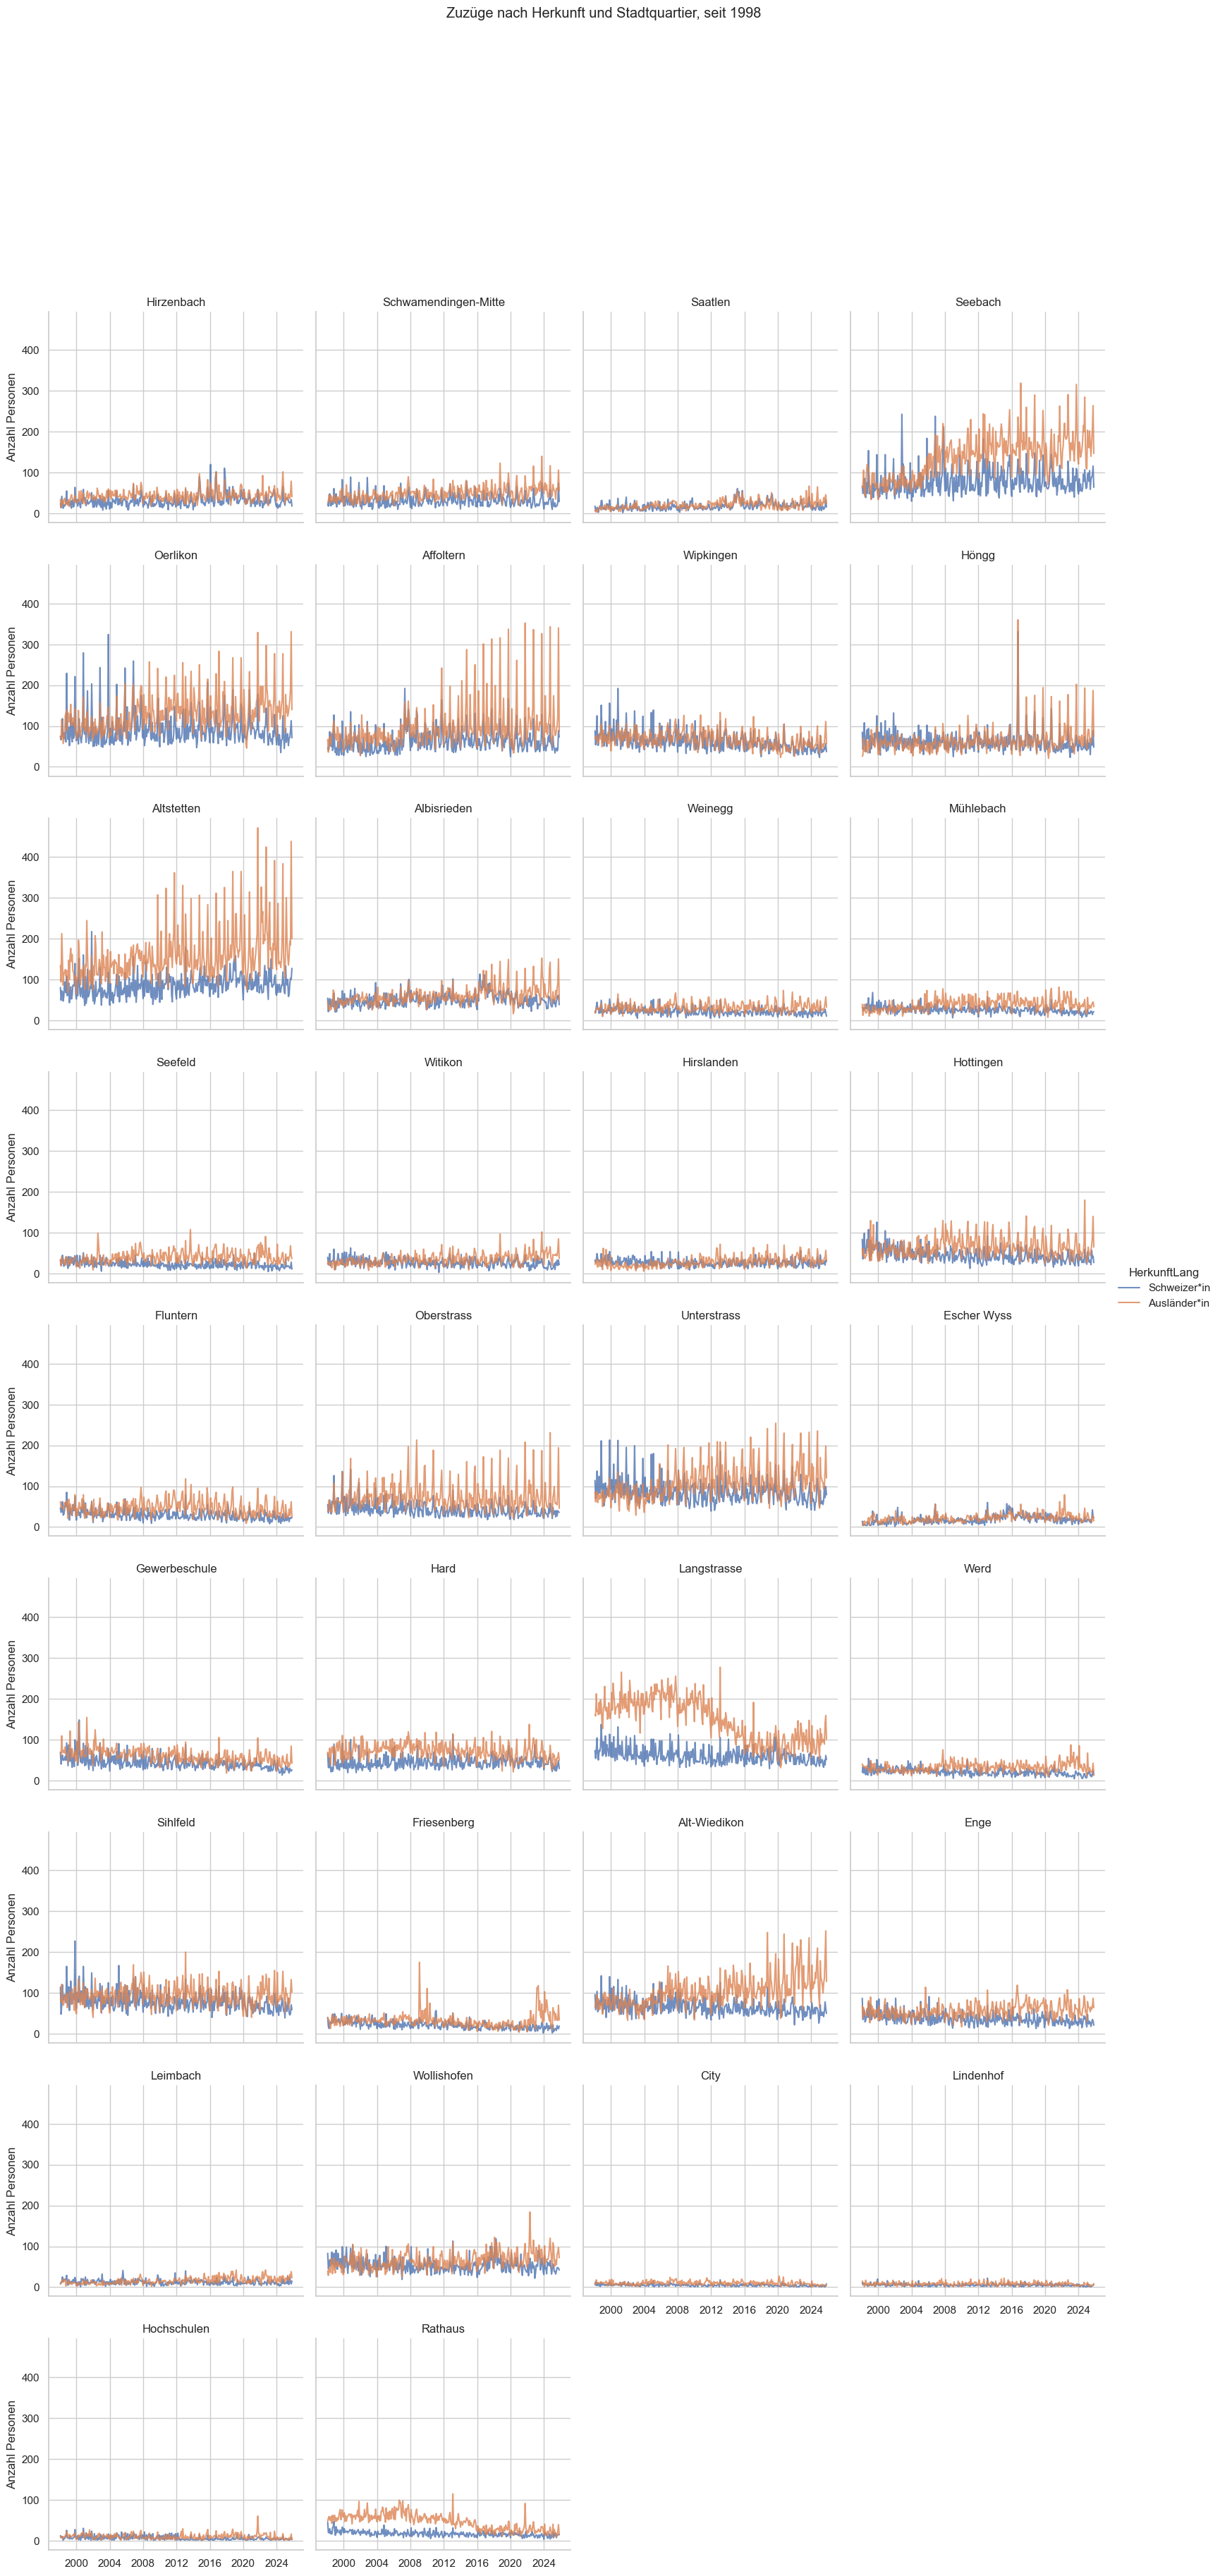

In [37]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('QuarCd', ascending=False)
    ,col = "QuarLang"
    ,hue = "HerkunftLang"
    ,col_wrap = 4
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDat"
    ,y = "sum_AnzZuzuWir"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Zuzüge nach Herkunft und Stadtquartier, seit "+str(int(data2betested.index.year.min()))   
)
faced_grid1

In [38]:
myFG1 = data2betested\
    .groupby(['StichtagDat','EreignisDatJahr','HerkunftCd', 'HerkunftLang', 'SexLang', 'SexCd']) \
    .agg(sum_AnzZuzuWir=('AnzZuzuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=True) 

myFG2 = data2betested\
    .groupby(['StichtagDat','EreignisDatJahr','HerkunftCd', 'HerkunftLang', 'AlterV20ueber80Sort_noDM', 'AlterV20ueber80Cd_noDM', 'AlterV20ueber80Kurz_noDM']) \
    .agg(sum_AnzZuzuWir=('AnzZuzuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=True) 


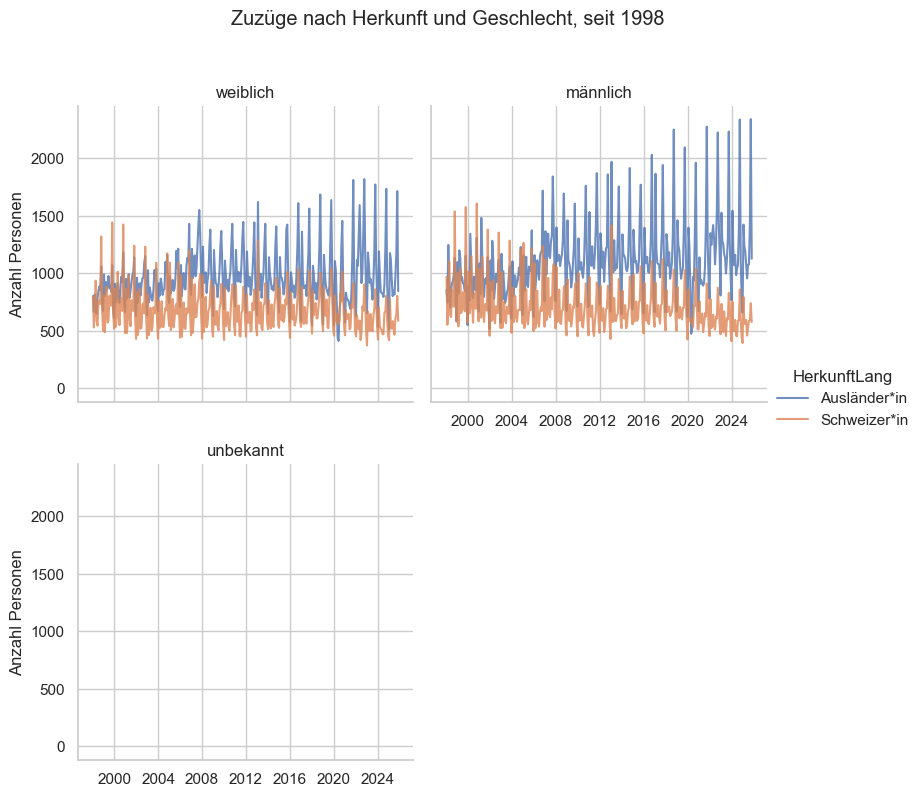

In [39]:
faced_grid2 = mypy_dv.plot_sns_facetgrid(
    data = myFG1.reset_index().sort_values('HerkunftCd', ascending=False)
    ,col = "SexLang"
    ,hue = "HerkunftLang"
    ,col_wrap = 2
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDat"
    ,y = "sum_AnzZuzuWir"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Zuzüge nach Herkunft und Geschlecht, seit "+str(int(data2betested.index.year.min()))   
)
faced_grid2

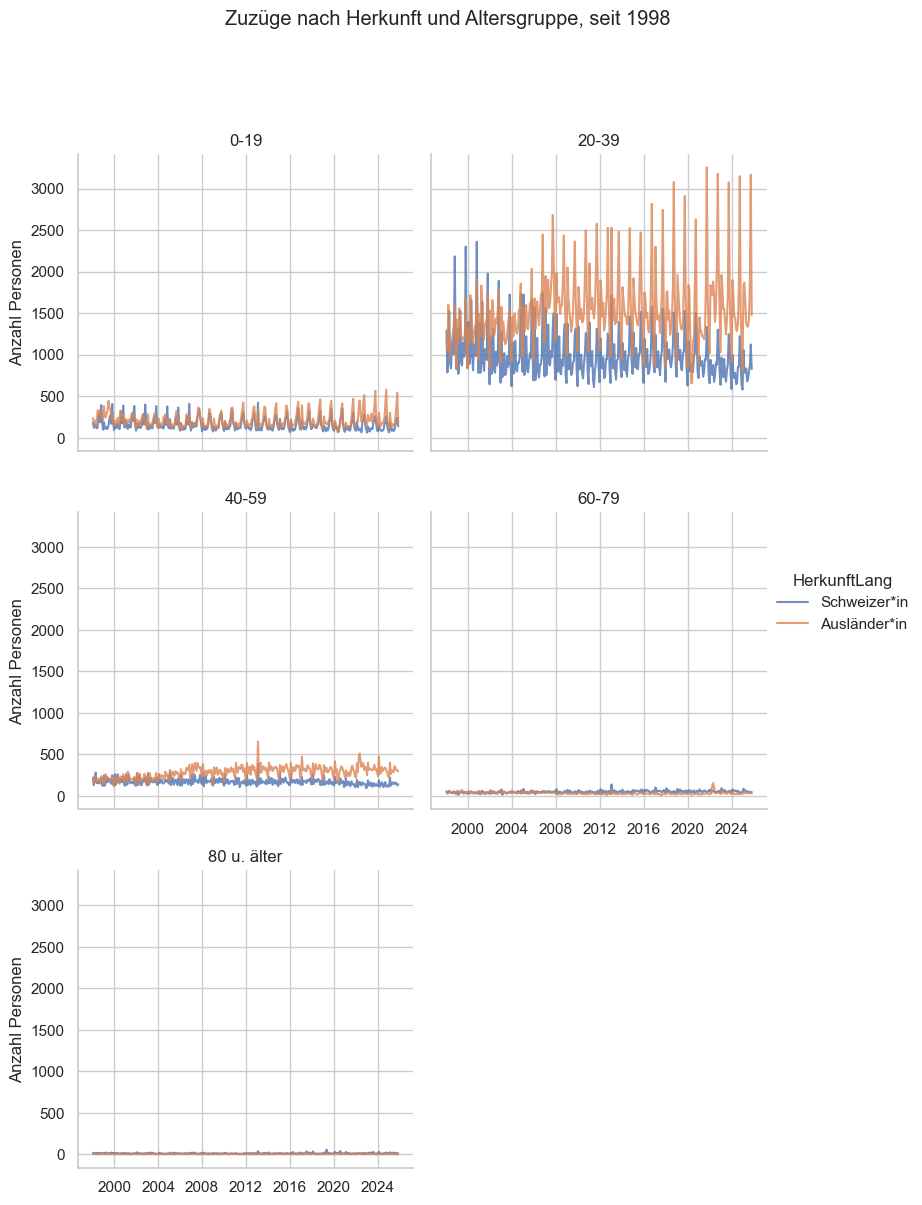

In [40]:
faced_grid3 = mypy_dv.plot_sns_facetgrid(
    data = myFG2.reset_index().sort_values('AlterV20ueber80Sort_noDM', ascending=True)
    ,col = "AlterV20ueber80Kurz_noDM"
    ,hue = "HerkunftLang"
    ,col_wrap = 2
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDat"
    ,y = "sum_AnzZuzuWir"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Zuzüge nach Herkunft und Altersgruppe, seit "+str(int(data2betested.index.year.min()))   
)
faced_grid3

In [41]:
data2betested.columns

Index(['EreignisDatJahr', 'EreignisDatMM', 'EreignisDatMonat', 'SexCd', 'SexLang',
       'AlterV20ueber80Sort_noDM', 'AlterV20ueber80Cd_noDM', 'AlterV20ueber80Kurz_noDM',
       'HerkunftCd', 'HerkunftLang', 'KreisCd', 'KreisLang', 'QuarCd', 'QuarLang', 'DatenstandCd',
       'DatenstandLang', 'AnzZuzuWir', 'StichtagDatJahr_str', 'EreignisDatMM_str'],
      dtype='object')

In [42]:
myFG4 = data2betested.loc[data_max_date]\
    .groupby(['StichtagDat','EreignisDatJahr','QuarCd', 'QuarLang','HerkunftCd', 'HerkunftLang', 'AlterV20ueber80Sort_noDM', 'AlterV20ueber80Cd_noDM', 'AlterV20ueber80Kurz_noDM']) \
    .agg(sum_AnzZuzuWir=('AnzZuzuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=True) 
myFG4

sum_AnzZuzuWir
StichtagDat EreignisDatJahr QuarCd QuarLang      HerkunftCd HerkunftLang AlterV20ueber80Sort_noDM AlterV20ueber80Cd_noDM AlterV20ueber80Kurz_noDM                
2025-10-31  2025-01-01      11     Rathaus       1          Schweizer*in 1                        1                      0-19                                   2
                            82     Mühlebach     2          Ausländer*in 1                        1                      0-19                                   3
                                                                         2                        2                      20-39                                 24
                                                                         3                        3                      40-59                                  6
                            83     Weinegg       1          Schweizer*in 1                        1                      0-19                                   1
...                                                                                                                                                           ...
                            51     Gewerbeschule 1          Schweizer*in 2                        2                      20-39                                 21
                                                                         3                        3                      40-59                                  4
                                                 2          Ausländer*in 2                        2                      20-39                                 34
                            52     Escher Wyss   1          Schweizer*in 1                        1                      0-19                                   1
                            123    Hirzenbach    2          Ausländer*in 3                        3                      40-59                                  4

[229 rows x 1 columns]

In [43]:
help(mypy_dv.plot_sns_facetgrid)

Help on function plot_sns_facetgrid in module my_py_dataviz_functions:

plot_sns_facetgrid(data, col, hue, col_wrap, height, x, y, **kwargs)
    Diese Funktion erstellt mit Seaborn eine faced grid lineplot.
    Doku dazu unter: 
    - https://seaborn.pydata.org/generated/seaborn.FacetGrid.html 
    - https://seaborn.pydata.org/examples/index.html
    
    Parameter (zwingend):
    - data (DataFrame): Die Daten, die für das Diagramm verwendet werden sollen.
    - col (str): Attribut für die Spalten des Grids.
    - hue(str): Kategorie für die Farbgebung.
    - col_wrap (num): Anzahl Grafiken pro Zeile.
    - x (str): Attribut der X-Achse
    - y (str):Attribut der Y-Achse
    
    Optionale Parameter:    
    - height (num): Höhe einer Grafik i.d.R 3-4
    - grafiktyp (str): Typen können sein: sns.lineplot, sns.scatterplot, sns.violinplot
    - xlabel (str): Beschriftung der X-Achse
    - ylabel (str): Beschriftung der Y-Achse
    - warning_status (str): Der Status der Warnmeldungen.'al

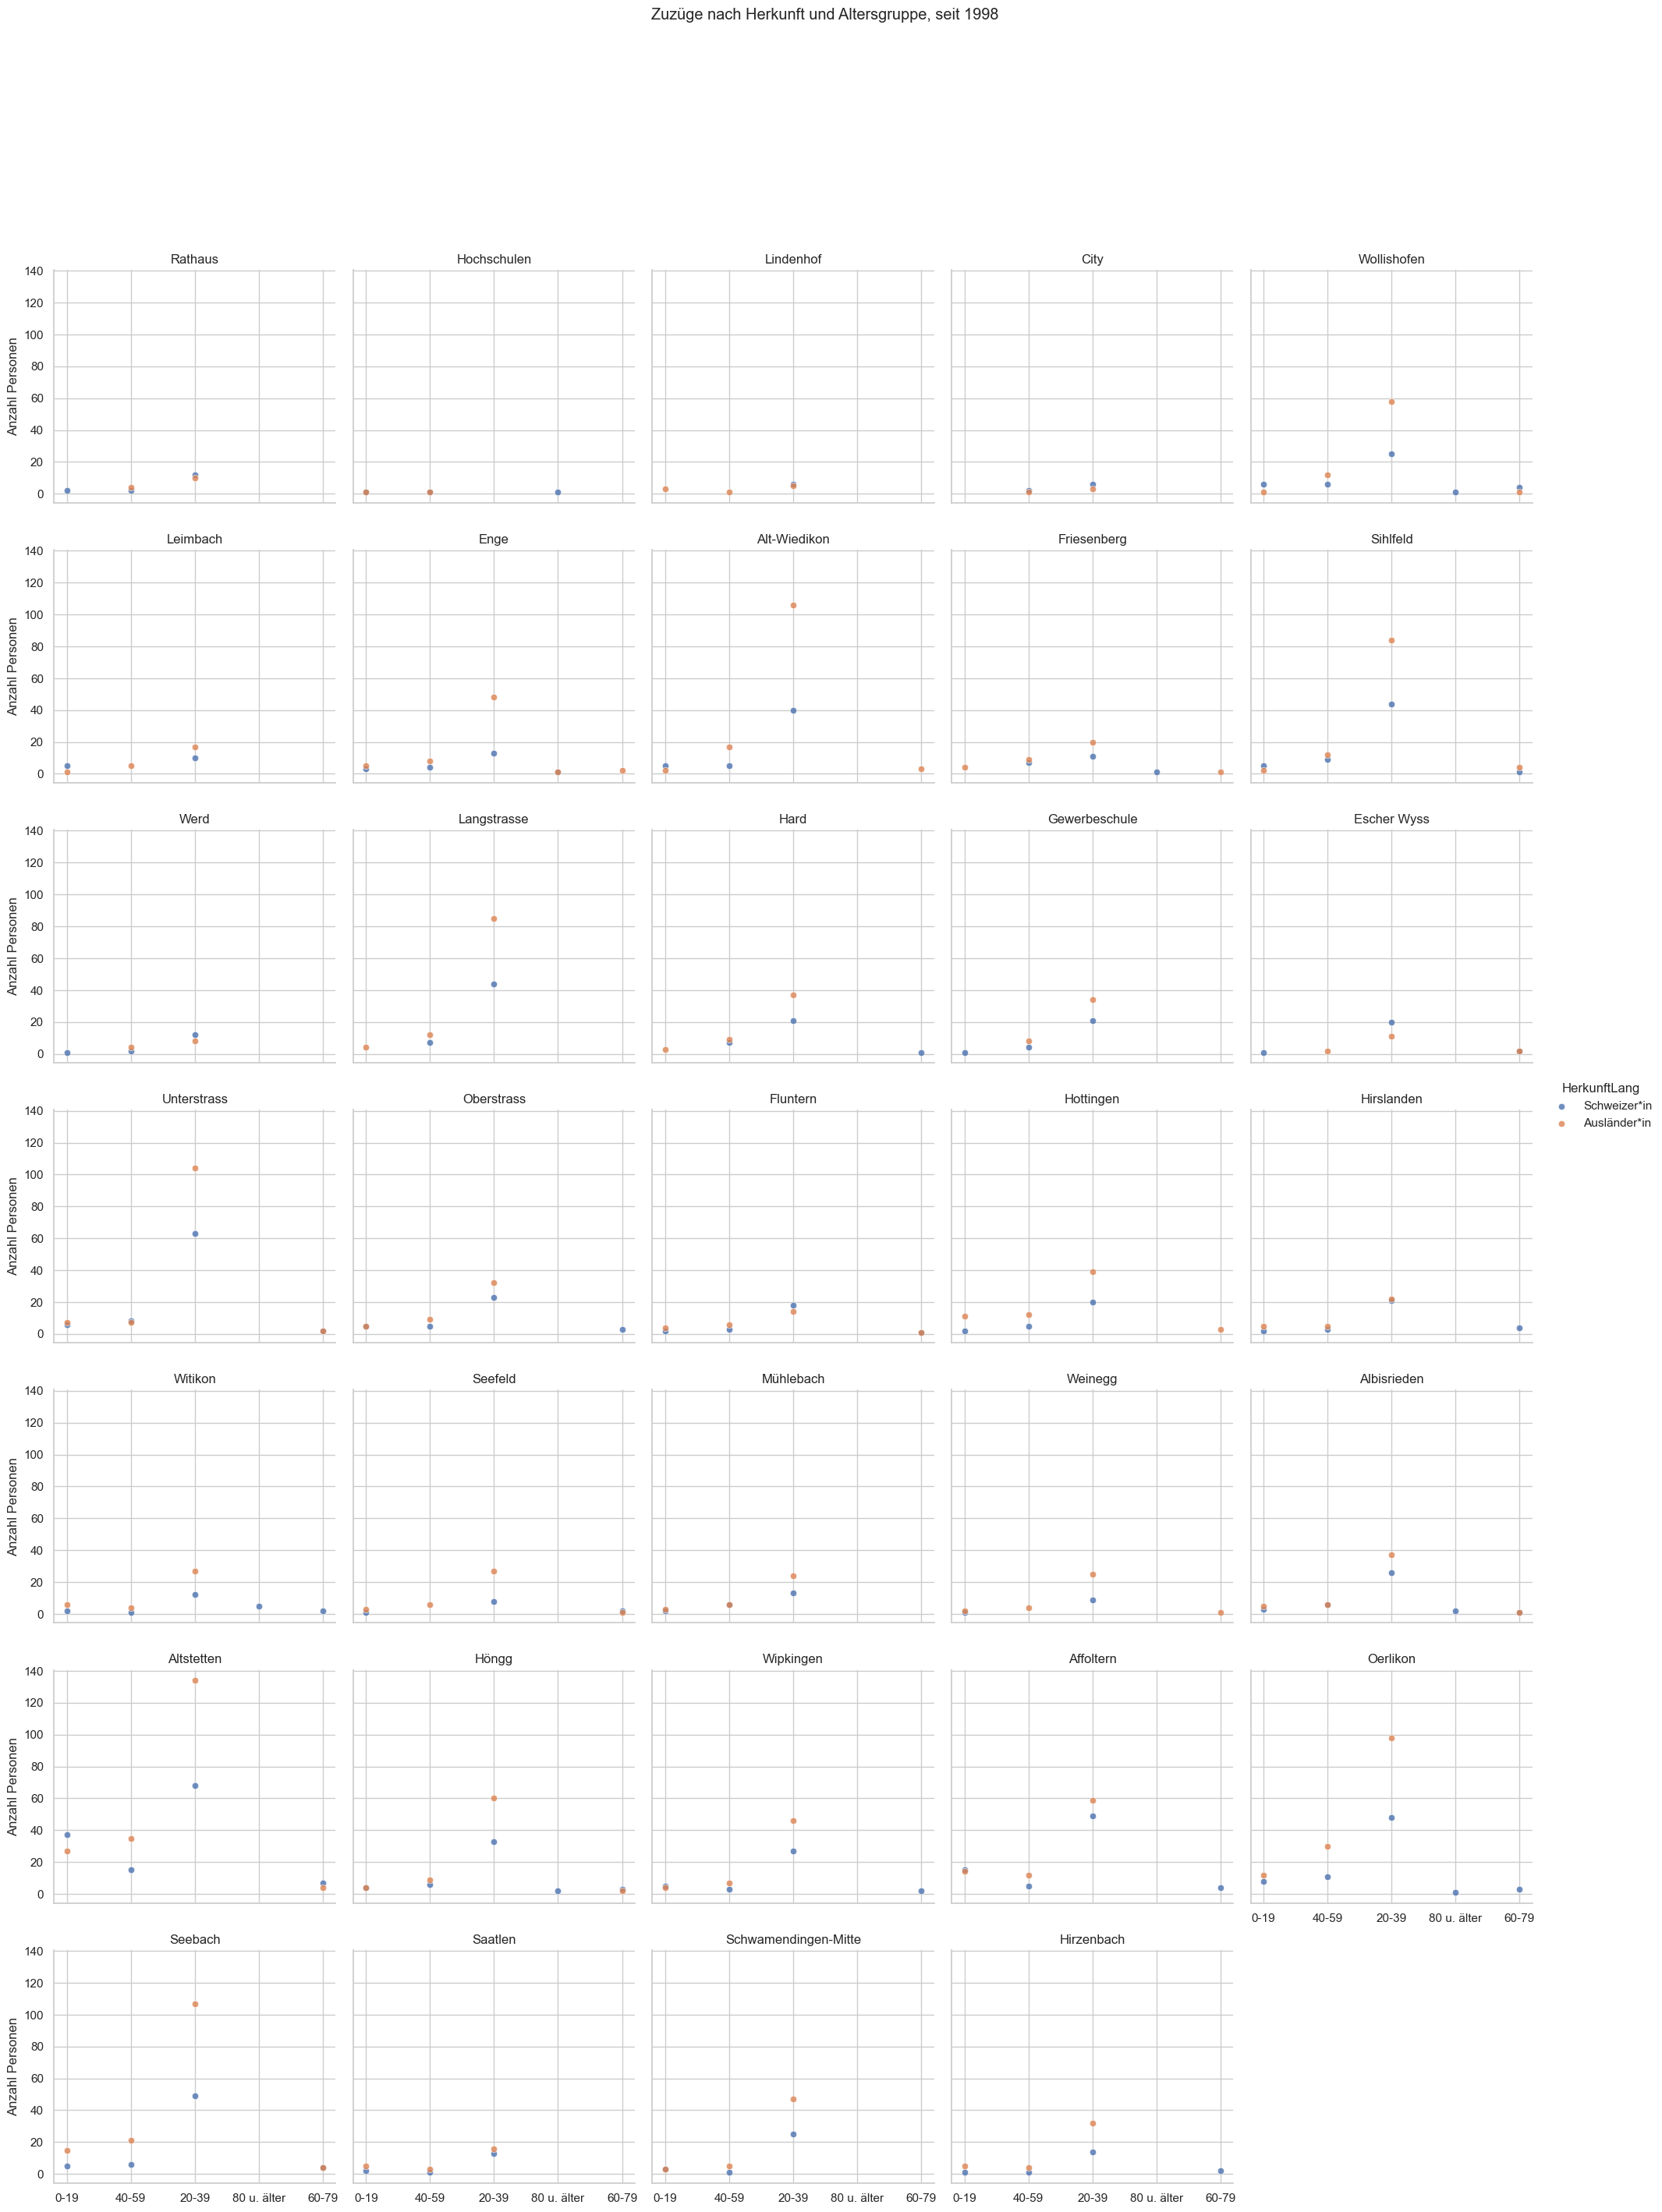

In [44]:
faced_grid4 = mypy_dv.plot_sns_facetgrid(
    data = myFG4.reset_index().sort_values('QuarCd', ascending=True)
    ,col = "QuarLang"
    ,hue = "HerkunftLang"
    ,col_wrap = 5
    ,grafiktyp = sns.scatterplot
    ,x = "AlterV20ueber80Kurz_noDM"
    ,y = "sum_AnzZuzuWir"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Zuzüge nach Herkunft und Altersgruppe, seit "+str(int(data2betested.index.year.min()))   
)
faced_grid4

### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

In [45]:
data2betested.columns

Index(['EreignisDatJahr', 'EreignisDatMM', 'EreignisDatMonat', 'SexCd', 'SexLang',
       'AlterV20ueber80Sort_noDM', 'AlterV20ueber80Cd_noDM', 'AlterV20ueber80Kurz_noDM',
       'HerkunftCd', 'HerkunftLang', 'KreisCd', 'KreisLang', 'QuarCd', 'QuarLang', 'DatenstandCd',
       'DatenstandLang', 'AnzZuzuWir', 'StichtagDatJahr_str', 'EreignisDatMM_str'],
      dtype='object')

In [46]:
myTreemapAgg = data2betested.loc["2020":data_max_date]   \
    .groupby(['StichtagDat', 'KreisLang','QuarLang','HerkunftLang', 'AlterV20ueber80Sort_noDM' , 'AlterV20ueber80Kurz_noDM' ]) \
    .agg(sum_AnzZuzuWir=('AnzZuzuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=False) 

myTreemapAgg.reset_index().head(4)

#.query("KreisLang ='Unbekannt'")\

,StichtagDat,KreisLang,QuarLang,HerkunftLang,AlterV20ueber80Sort_noDM,AlterV20ueber80Kurz_noDM,sum_AnzZuzuWir
0,2025-10-31,Kreis 9,Altstetten,Schweizer*in,4,60-79,7
1,2025-10-31,Kreis 2,Leimbach,Ausländer*in,1,0-19,1
2,2025-10-31,Kreis 2,Enge,Schweizer*in,3,40-59,4
3,2025-10-31,Kreis 2,Enge,Schweizer*in,2,20-39,13


In [47]:
time_slot = data_max_date

In [48]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTreemapAgg.loc[time_slot].reset_index()
    ,levels=['KreisLang','QuarLang','HerkunftLang', 'AlterV20ueber80Kurz_noDM']
    ,values="sum_AnzZuzuWir"
    ,color="HerkunftLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey', 'Erwerbstätige':'#99C32E', 'Nichterwerbspersonen':'#7B4100', 'Erwerbslose':'#DB247D'}  
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Zuzüger*innen nach Stadtkreis, Quartier, Alter und Herkunft, "+time_slot

)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000001943BA115D0>, 'KreisLang', 'QuarLang', 'HerkunftLang', 'AlterV20ueber80Kurz_noDM']
Typ von path: <class 'list'>


In [49]:
treeMap2 = mypy_dv.plot_px_treemap(
    data=myTreemapAgg.loc[time_slot].reset_index()
    ,levels=['HerkunftLang', 'AlterV20ueber80Kurz_noDM','KreisLang','QuarLang',]
    ,values="sum_AnzZuzuWir"
    ,color="AlterV20ueber80Kurz_noDM"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey', 'Erwerbstätige':'#99C32E', 'Nichterwerbspersonen':'#7B4100', 'Erwerbslose':'#DB247D'}  
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Zuzüger*innen nach Stadtkreis, Quartier, Alter und Herkunft,"+time_slot

)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x0000019440FADD50>, 'HerkunftLang', 'AlterV20ueber80Kurz_noDM', 'KreisLang', 'QuarLang']
Typ von path: <class 'list'>


In [50]:
treeMap3 = mypy_dv.plot_px_treemap(
    data=myTreemapAgg.loc[time_slot].reset_index().sort_values("AlterV20ueber80Sort_noDM", ascending=True)
    ,levels=['AlterV20ueber80Kurz_noDM','KreisLang','QuarLang','HerkunftLang']
    ,values="sum_AnzZuzuWir"
    ,color="KreisLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey', 'Erwerbstätige':'#99C32E', 'Nichterwerbspersonen':'#7B4100', 'Erwerbslose':'#DB247D'}  
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Zuzüger*innen nach Stadtkreis, Quartier, Alter und Herkunft,"+time_slot

)
treeMap3

path: [<plotly.express._special_inputs.Constant object at 0x0000019440FADD50>, 'AlterV20ueber80Kurz_noDM', 'KreisLang', 'QuarLang', 'HerkunftLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

Record auf Sharepoint: 

**[Neuer Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=515&e=S5fUjW)**

---------------------------------------------------------------------------